In [10]:
# Install SQLite library for Python
!pip install sqlalchemy sqlite3-to-mysql pandas

# Import necessary libraries
import sqlite3
import pandas as pd


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.9/33.9 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 17.2 MB/s eta 0:00:00


In [11]:
# Download the Chinook SQLite database
!wget https://github.com/lerocha/chinook-database/raw/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite -O Chinook_Sqlite.sqlite

# Connect to the database
conn = sqlite3.connect("Chinook_Sqlite.sqlite")
cursor = conn.cursor()

# Check available tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
tables


--2025-08-11 23:35:20--  https://github.com/lerocha/chinook-database/raw/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite [following]
--2025-08-11 23:35:20--  https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1067008 (1.0M) [application/octet-stream]
Saving to: ‘Chinook_Sqlite.sqlite’

Chinook_Sqlite.sqli 100%[===================>]   1.02M  --.-KB/

[('Album',),
 ('Artist',),
 ('Customer',),
 ('Employee',),
 ('Genre',),
 ('Invoice',),
 ('InvoiceLine',),
 ('MediaType',),
 ('Playlist',),
 ('PlaylistTrack',),
 ('Track',)]

# **Top-Selling Products**

In [13]:
query_top_selling = """
SELECT t.Name AS TrackName, SUM(ii.Quantity) AS TotalSold
FROM invoiceLine ii
JOIN track t ON ii.TrackId = t.TrackId
GROUP BY t.Name
ORDER BY TotalSold DESC
LIMIT 5;
"""
top_selling = pd.read_sql_query(query_top_selling, conn)
top_selling


,TrackName,TotalSold
0,The Trooper,5
1,Untitled,4
2,The Number Of The Beast,4
3,Sure Know Something,4
4,Hallowed Be Thy Name,4


# **Revenue Per Region**

In [14]:
query_revenue_region = """
SELECT c.Country, ROUND(SUM(ii.UnitPrice * ii.Quantity), 2) AS TotalRevenue
FROM invoiceLine ii
JOIN invoice i ON ii.InvoiceId = i.InvoiceId
JOIN customer c ON i.CustomerId = c.CustomerId
GROUP BY c.Country
ORDER BY TotalRevenue DESC;
"""
revenue_region = pd.read_sql_query(query_revenue_region, conn)
revenue_region


,Country,TotalRevenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


# **Monthly** **Performance**

In [15]:
query_monthly_performance = """
SELECT STRFTIME('%Y-%m', i.InvoiceDate) AS Month,
       ROUND(SUM(ii.UnitPrice * ii.Quantity), 2) AS MonthlyRevenue
FROM invoiceLine ii
JOIN invoice i ON ii.InvoiceId = i.InvoiceId
GROUP BY Month
ORDER BY Month;
"""
monthly_performance = pd.read_sql_query(query_monthly_performance, conn)
monthly_performance


,Month,MonthlyRevenue
0,2009-01,35.64
1,2009-02,37.62
2,2009-03,37.62
3,2009-04,37.62
4,2009-05,37.62
5,2009-06,37.62
6,2009-07,37.62
7,2009-08,37.62
8,2009-09,37.62
9,2009-10,37.62


# **Combine Product and Sales Tables**

In [16]:
query_combined = """
SELECT t.Name AS TrackName, g.Name AS Genre, SUM(ii.Quantity) AS TotalSold,
       ROUND(SUM(ii.UnitPrice * ii.Quantity), 2) AS Revenue
FROM invoiceline ii
JOIN track t ON ii.TrackId = t.TrackId
JOIN genre g ON t.GenreId = g.GenreId
GROUP BY t.Name, g.Name
ORDER BY Revenue DESC
LIMIT 10;
"""
combined_sales = pd.read_sql_query(query_combined, conn)
combined_sales


,TrackName,Genre,TotalSold,Revenue
0,Gay Witch Hunt,TV Shows,2,3.98
1,Hot Girl,TV Shows,2,3.98
2,How to Stop an Exploding Man,Drama,2,3.98
3,Phyllis's Wedding,Comedy,2,3.98
4,Pilot,TV Shows,2,3.98
5,The Fix,Drama,2,3.98
6,The Woman King,Science Fiction,2,3.98
7,Walkabout,TV Shows,2,3.98
8,Eruption,Rock,4,3.96
9,Sure Know Something,Rock,4,3.96


# **Ranking Products with a Window Function**

In [21]:
query_ranking = """
SELECT t.Name AS TrackName,
       SUM(ii.Quantity) AS TotalSold,
       RANK() OVER (ORDER BY SUM(ii.Quantity) DESC) AS SalesRank
FROM invoiceline ii
JOIN track t ON ii.TrackId = t.TrackId
GROUP BY t.Name;
"""
ranking = pd.read_sql_query(query_ranking, conn)
ranking.head(40)


,TrackName,TotalSold,SalesRank
0,The Trooper,5,1
1,Untitled,4,2
2,The Number Of The Beast,4,2
3,Sure Know Something,4,2
4,Hallowed Be Thy Name,4,2
5,Eruption,4,2
6,Where Eagles Dare,3,7
7,Welcome Home (Sanitarium),3,7
8,Sweetest Thing,3,7
9,Surrender,3,7


# **Visualization**

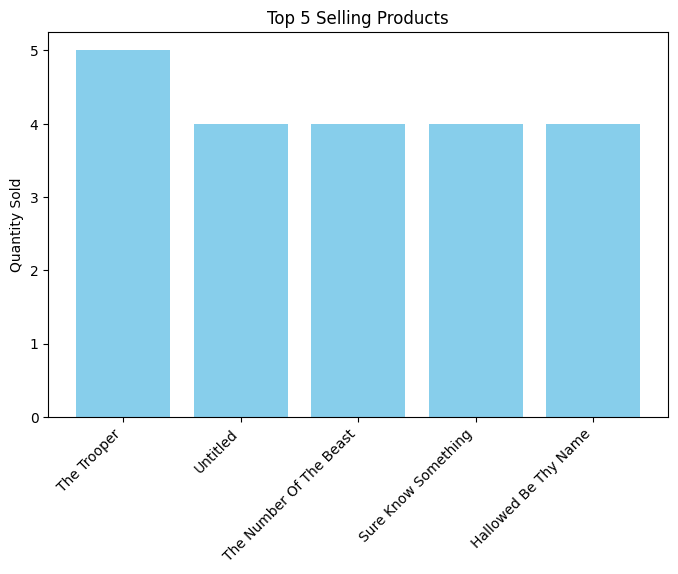

In [22]:
import matplotlib.pyplot as plt

# Top Selling Products Bar Chart
plt.figure(figsize=(8,5))
plt.bar(top_selling['TrackName'], top_selling['TotalSold'], color='skyblue')
plt.title("Top 5 Selling Products")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha="right")
plt.show()


# **Additional Analytical Queries**


## **Best Customers by Lifetime Value**

In [24]:
query_best_customers = """
SELECT c.FirstName || ' ' || c.LastName AS CustomerName,
       c.Country,
       ROUND(SUM(ii.UnitPrice * ii.Quantity), 2) AS TotalSpent
FROM invoiceline ii
JOIN invoice i ON ii.InvoiceId = i.InvoiceId
JOIN customer c ON i.CustomerId = c.CustomerId
GROUP BY c.CustomerId
ORDER BY TotalSpent DESC
LIMIT 10;
"""
best_customers = pd.read_sql_query(query_best_customers, conn)
best_customers


,CustomerName,Country,TotalSpent
0,Helena Holý,Czech Republic,49.62
1,Richard Cunningham,USA,47.62
2,Luis Rojas,Chile,46.62
3,Hugh O'Reilly,Ireland,45.62
4,Ladislav Kovács,Hungary,45.62
5,Fynn Zimmermann,Germany,43.62
6,Julia Barnett,USA,43.62
7,Frank Ralston,USA,43.62
8,Victor Stevens,USA,42.62
9,Astrid Gruber,Austria,42.62


# **Most Popular Genres**

In [25]:
query_popular_genres = """
SELECT g.Name AS Genre,
       SUM(ii.Quantity) AS TotalSold
FROM invoiceline ii
JOIN track t ON ii.TrackId = t.TrackId
JOIN genre g ON t.GenreId = g.GenreId
GROUP BY g.Name
ORDER BY TotalSold DESC
LIMIT 5;
"""
popular_genres = pd.read_sql_query(query_popular_genres, conn)
popular_genres


,Genre,TotalSold
0,Rock,835
1,Latin,386
2,Metal,264
3,Alternative & Punk,244
4,Jazz,80


# **Average Order Value by Country**

In [26]:
query_avg_order_value = """
SELECT c.Country,
       ROUND(AVG(i.Total), 2) AS AvgOrderValue
FROM invoice i
JOIN customer c ON i.CustomerId = c.CustomerId
GROUP BY c.Country
ORDER BY AvgOrderValue DESC
LIMIT 10;
"""
avg_order_value = pd.read_sql_query(query_avg_order_value, conn)
avg_order_value


,Country,AvgOrderValue
0,Chile,6.66
1,Ireland,6.52
2,Hungary,6.52
3,Czech Republic,6.45
4,Austria,6.09
5,Finland,5.95
6,Netherlands,5.80
7,India,5.79
8,USA,5.75
9,Norway,5.66


# **Visualization**

In [27]:
import plotly.express as px

# Interactive revenue per region
fig_region = px.bar(revenue_region, x='Country', y='TotalRevenue',
                    title='Revenue by Country', color='TotalRevenue')
fig_region.show()

# Interactive monthly performance trend
fig_monthly = px.line(monthly_performance, x='Month', y='MonthlyRevenue',
                      title='Monthly Revenue Trend')
fig_monthly.show()

# Interactive genre popularity
fig_genres = px.pie(popular_genres, names='Genre', values='TotalSold',
                    title='Top 5 Most Popular Genres')
fig_genres.show()


# **The analysis of the Chinook database revealed several key insights:**

**First**, the top-selling products were identified, with "The Trooper" leading in terms of quantity sold.

**Second**, a revenue breakdown by country showed that the USA generated the highest total revenue, followed by Canada and France.

**Third**, a monthly performance analysis indicated fluctuations in revenue over time, with some months showing higher sales than others.

**Fourth**, combining product and sales data allowed for a view of top-performing tracks by both quantity and revenue, highlighting some tracks from TV Shows and Rock genres.

**Fifth**, a sales ranking using a window function provided a more comprehensive view of product performance beyond just the top few.

**Finally**, additional analyses identified the best customers by lifetime value, the most popular genres (with Rock being the most popular), and the average order value by country.

These findings provide a good overview of the sales performance, customer behavior, and product popularity within the Chinook database.

